In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit

In [30]:
df_new = pd.read_csv(r"C:\Users\NKUE0003\Downloads\NPiekstra_DATA_2026-07-14_1405.csv")
df_new["redcap_repeat_instance"] = (
    df_new["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)
# relevant_columns = ["npi_left", "npi_right", "pupil_size_left", "pupil_size_right", "pupil_min_left", "pupil_min_right", "ch_left", "ch_right", "const_velocity_left", "const_velocity_right", "max_const_velocity_left", "max_const_velocity_right", "dilat_velocity_left", "dilat_velocity_right", "latency_left", "latency_right"]
# new_columns = [col for col in df_new.columns if col[:col.find("_t")].lower() in relevant_columns]
# df_new = df_new.dropna(subset=new_columns)
df_new = df_new[df_new["redcap_event_name"] == 'day_1_exam_t0__t4_arm_1']
df_new['record_id'].duplicated().sum()  # should be 0
columns_to_drop = ['redcap_event_name', 'redcap_repeat_instrument', 'redcap_repeat_instance'] + [col for col in df_new.columns if 'which_pupillometer' in col] + [col for col in df_new.columns if 'exploratory_pupillometry' in col] + [col for col in df_new.columns if "time_pupillometry" in col]
df_new.drop(columns=columns_to_drop, inplace=True)
long_df = pd.wide_to_long(
    df_new,
    stubnames=[
        'npi_right', 'npi_left',
        'pupil_size_right', 'pupil_size_left',
        'pupil_min_right', 'pupil_min_left',
        'ch_right', 'ch_left',
        'const_velocity_right', 'const_velocity_left',
        'latency_right', 'latency_left',
        'dilat_velocity_right', 'dilat_velocity_left',
        'max_const_velocity_right', 'max_const_velocity_left'
    ],
    i='record_id',
    j='redcap_repeat_instance',
    sep='_',
    suffix=r't\d+'
).reset_index()

long_df = pd.wide_to_long(
    long_df,
    stubnames=[
        'npi',
        'pupil_size',
        'pupil_min',
        'ch',
        'const_velocity',
        'latency',
        'dilat_velocity',
        'max_const_velocity'
    ],
    i=['record_id', 'redcap_repeat_instance'],
    j='eye',
    sep='_',
    suffix=r'(left|right)'
).reset_index()
long_df = long_df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch",
    "const_velocity", "max_const_velocity",
    "dilat_velocity", "latency"
])
long_df["record_id"] += 1000
long_df["eye"] = long_df["eye"].map({"left": 0, "right": 1})
long_df

,record_id,redcap_repeat_instance,eye,npi,pupil_size,pupil_min,ch,const_velocity,latency,dilat_velocity,max_const_velocity
106,1054,t1,1,1.0,5.86,5.27,10.0,1.21,0.27,0.42,1.68
107,1054,t1,0,1.6,5.68,4.80,15.0,1.52,0.40,0.53,1.93
108,1055,t1,1,1.2,4.92,4.47,9.0,0.62,0.23,0.40,0.94
109,1055,t1,0,2.7,3.84,3.40,11.0,0.69,0.23,0.31,1.33
110,1056,t1,1,0.7,5.71,5.42,5.0,0.56,0.20,0.34,1.06
...,...,...,...,...,...,...,...,...,...,...,...
571,1070,t4,0,4.4,3.70,2.57,31.0,1.67,0.20,0.91,3.54
572,1071,t4,1,4.3,4.47,2.89,35.0,2.39,0.23,1.61,4.39
573,1071,t4,0,3.6,4.59,3.34,27.0,1.42,0.27,1.43,2.99
574,1072,t4,1,4.3,4.07,2.76,32.0,1.97,0.23,1.02,3.56


In [31]:
#Data
df = pd.read_csv(r"L:\\Auditdata\\CONNECT-ME\\DTU\\FrederikWeinan_Thesis\\Modified_Pupilometri\\NPImeaures_noCHerror.csv")

df["eye"] = df["eye"].map({"left": 0, "right": 1})

df["redcap_repeat_instance"] = (
    df["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)
df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch",
    "const_velocity", "max_const_velocity",
    "dilat_velocity", "latency"
])

df_l = pd.read_csv(r"L:\Auditdata\CONNECT-ME\DTU\FrederikWeinan_Thesis\Pupilometri\HC_left_NPi.csv")
df_r = pd.read_csv(r"L:\Auditdata\CONNECT-ME\DTU\FrederikWeinan_Thesis\Pupilometri\HC_right_NPi.csv")
df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)

In [32]:
df = pd.concat([df, long_df], ignore_index=True)
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch"
])
df

,record_id,redcap_repeat_instance,eye,npi,pupil_size,pupil_min,ch,const_velocity,max_const_velocity,latency,dilat_velocity
0,1,0,0,4.5,1.98,1.70,14.0,0.98,1.31,0.23,0.20
1,1,1,0,4.5,2.08,1.79,14.0,0.89,1.44,0.27,0.20
2,1,2,0,4.6,2.09,1.75,16.0,0.97,1.15,0.20,0.31
3,1,3,0,4.6,2.16,1.82,16.0,1.07,1.41,0.17,0.27
4,1,4,0,4.6,2.59,2.07,20.0,1.25,2.30,0.20,0.38
...,...,...,...,...,...,...,...,...,...,...,...
2069,1070,t4,0,4.4,3.70,2.57,31.0,1.67,3.54,0.20,0.91
2070,1071,t4,1,4.3,4.47,2.89,35.0,2.39,4.39,0.23,1.61
2071,1071,t4,0,3.6,4.59,3.34,27.0,1.42,2.99,0.27,1.43
2072,1072,t4,1,4.3,4.07,2.76,32.0,1.97,3.56,0.23,1.02


Outlier detection: ((Max - Min) / max) - ch > 0.01

In [33]:
df.iloc[np.where(abs((df["pupil_size"] - df["pupil_min"]) / df["pupil_size"] - df["ch"] / 100) > 0.01)]

,record_id,redcap_repeat_instance,eye,npi,pupil_size,pupil_min,ch,const_velocity,max_const_velocity,latency,dilat_velocity


In [34]:
def z_score(x, mean, std):
    return (x - mean) / std

# use the z-scores from healthy controls

df["z_pupil_size"] = z_score(df["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df["z_pupil_min"]  = z_score(df["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df["z_ch"] = z_score(df["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df["z_const_velocity"] = z_score(df["const_velocity"], df_HC["const_velocity"].dropna().mean(),df_HC["const_velocity"].dropna().std())
df["z_max_const_velocity"] = z_score(df["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df["z_dilat_velocity"] = z_score(df["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df["z_latency"] = z_score(df["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())
df.to_csv("done.csv")
df

,record_id,redcap_repeat_instance,eye,npi,pupil_size,pupil_min,ch,const_velocity,max_const_velocity,latency,dilat_velocity,z_pupil_size,z_pupil_min,z_ch,z_const_velocity,z_max_const_velocity,z_dilat_velocity,z_latency
0,1,0,0,4.5,1.98,1.70,14.0,0.98,1.31,0.23,0.20,-2.748735,-1.838619,-3.669776,-2.576491,-3.051085,-2.927427,-0.254007
1,1,1,0,4.5,2.08,1.79,14.0,0.89,1.44,0.27,0.20,-2.652960,-1.720219,-3.669776,-2.723850,-2.906082,-2.927427,0.804354
2,1,2,0,4.6,2.09,1.75,16.0,0.97,1.15,0.20,0.31,-2.643383,-1.772841,-3.338569,-2.592864,-3.229550,-2.518347,-1.047777
3,1,3,0,4.6,2.16,1.82,16.0,1.07,1.41,0.17,0.27,-2.576340,-1.680752,-3.338569,-2.429132,-2.939544,-2.667103,-1.841548
4,1,4,0,4.6,2.59,2.07,20.0,1.25,2.30,0.20,0.38,-2.164509,-1.351864,-2.676154,-2.134414,-1.946832,-2.258023,-1.047777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069,1070,t4,0,4.4,3.70,2.57,31.0,1.67,3.54,0.20,0.91,-1.101409,-0.694087,-0.854515,-1.446738,-0.563727,-0.287003,-1.047777
2070,1071,t4,1,4.3,4.47,2.89,35.0,2.39,4.39,0.23,1.61,-0.363944,-0.273109,-0.192100,-0.267866,0.384369,2.316232,-0.254007
2071,1071,t4,0,3.6,4.59,3.34,27.0,1.42,2.99,0.27,1.43,-0.249014,0.318890,-1.516929,-1.856069,-1.177201,1.646829,0.804354
2072,1072,t4,1,4.3,4.07,2.76,32.0,1.97,3.56,0.23,1.02,-0.747043,-0.444131,-0.688911,-0.955542,-0.541419,0.122077,-0.254007


In [35]:
from scipy.spatial import cKDTree

match_features = df[["z_pupil_size", "z_pupil_min"]].values
tree = cKDTree(match_features)

# Find par/naboer inden for en lille tolerance
tolerance = 0.1
pairs = tree.query_pairs(r=tolerance)

results = []
for i, j in pairs:
    row_i, row_j = df.iloc[i], df.iloc[j]
    lat_diff = row_i["z_latency"] - row_j["z_latency"]
    npi_diff = row_i["npi"] - row_j["npi"]
    if abs(lat_diff) > 0.5:  # kun par hvor latency reelt adskiller sig
        results.append({
            "record_id_i": row_i["record_id"], "record_id_j": row_j["record_id"],
            "lat_diff": lat_diff,
            "npi_diff": npi_diff,
            "size_diff": row_i["z_pupil_size"] - row_j["z_pupil_size"],
            "min_diff": row_i["z_pupil_min"] - row_j["z_pupil_min"],
        })

matched_df = pd.DataFrame(results)
matched_df.describe()

,record_id_i,record_id_j,lat_diff,npi_diff,size_diff,min_diff
count,17939.000000,17939.000000,17939.000000,17939.000000,17939.000000,17939.000000
mean,103.555995,163.698422,-0.000015,-0.004521,-0.000310,0.000093
std,81.291340,150.095970,1.985102,0.212897,0.049067,0.050060
min,1.000000,1.000000,-8.996069,-0.900000,-0.095775,-0.092089
25%,43.000000,87.000000,-1.587542,-0.100000,-0.038310,-0.039467
50%,93.000000,154.000000,-0.793771,0.000000,0.000000,0.000000
75%,156.000000,213.000000,1.587542,0.100000,0.038310,0.039467
max,1072.000000,1072.000000,10.583610,0.800000,0.095775,0.092089


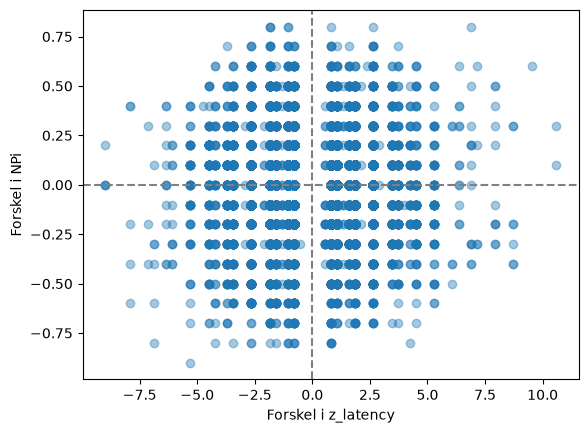

In [36]:
plt.scatter(matched_df["lat_diff"], matched_df["npi_diff"], alpha=0.4)
plt.xlabel("Forskel i z_latency")
plt.ylabel("Forskel i NPi")
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.savefig("outputs/latency_vs_npi_diff.pdf", dpi=1200)

In [37]:
def logit_transform(y, y_min=0.0, y_max=5.0, eps=1e-6):
    """
    Logit-transform a bounded target.
    """
    y_scaled = (y - y_min) / (y_max - y_min)
    y_scaled = np.clip(y_scaled, eps, 1 - eps)
    return np.log(y_scaled / (1 - y_scaled))


def inverse_logit_transform(z, y_min=0.0, y_max=5.0):
    """
    Inverse logit-transform back to original scale.
    """
    y_scaled = 1 / (1 + np.exp(-z))
    return y_min + (y_max - y_min) * y_scaled

In [38]:
# from pysr import PySRRegressor
# import sympy

# y = df["npi"]
# y = logit_transform(y)
# X = df[[
# "pupil_size",
# "pupil_min",
# "ch"
# ]]
# X

# model = PySRRegressor(
#     niterations=200,
#     binary_operators=["+", "-", "*", "/"],
#     unary_operators=["exp", "square", "logistic(x) = 1 / (1 + exp(-x))"],  
#     extra_sympy_mappings={"logistic": lambda x: 1 / (1 + sympy.exp(-x))},
#     maxsize=20,                      # cap expression complexity
#     model_selection="best",          # picks best accuracy/complexity tradeoff point
#     loss="loss(x, y) = (x - y)^2",   # fit on logit-scale z, not raw NPi
#     complexity_of_operators={"exp": 3, "logistic": 3},  # penalize nonlinear ops more
# )

# model.fit(X, y)
# print(model.equations_)   # Pareto front: complexity vs loss

# from pysr import PySRRegressor
# import sympy

# model = PySRRegressor(
#     niterations=1000,
#     populations=30,
#     maxsize=10,

#     binary_operators=[
#         "+",
#         "-",
#         "*",
#         "/",
#     ],

#     unary_operators=[
#         "sqrt",
#         "abs",
#         "tanh",
#         "square",
#         "log",
#         "exp",]
#    )
# model.fit(X, y)

In [39]:
TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
   "z_ch",
    "z_const_velocity",
    "z_max_const_velocity",
    "z_latency",
    "z_dilat_velocity"
]

X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values
groups = df[GROUP].values

y = (y_raw - 0) / (5 - 0)

eps = 1e-6
y = np.clip(y, eps, 1 - eps)

z = np.log(y / (1 - y))

X_trans = X.copy()

In [40]:
#Gam fit
gam = LinearGAM(
    s(0, n_splines=20) + # pupil size 
    s(1,constraints='monotonic_dec',  n_splines=10) +  # pupil min
    s(2, constraints='monotonic_inc', n_splines=10) +  # CH
    l(3) +  
    l(4) +  
    l(5)+l(6))

from sklearn.neighbors import KernelDensity

kde = KernelDensity(bandwidth=0.3).fit(z.reshape(-1,1))
log_dens = kde.score_samples(z.reshape(-1,1))
density_weights = 1 / np.exp(log_dens)
density_weights /= density_weights.mean()
cap = np.percentile(density_weights, 95)
density_weights_capped = np.clip(density_weights, None, cap)
density_weights_capped /= density_weights_capped.mean()

gam.gridsearch(X_trans, z, weights=density_weights_capped)

# gam.gridsearch(X_trans, z)


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + l(3) + l(4) + l(5) + l(6) + intercept, 
   tol=0.0001, verbose=False)

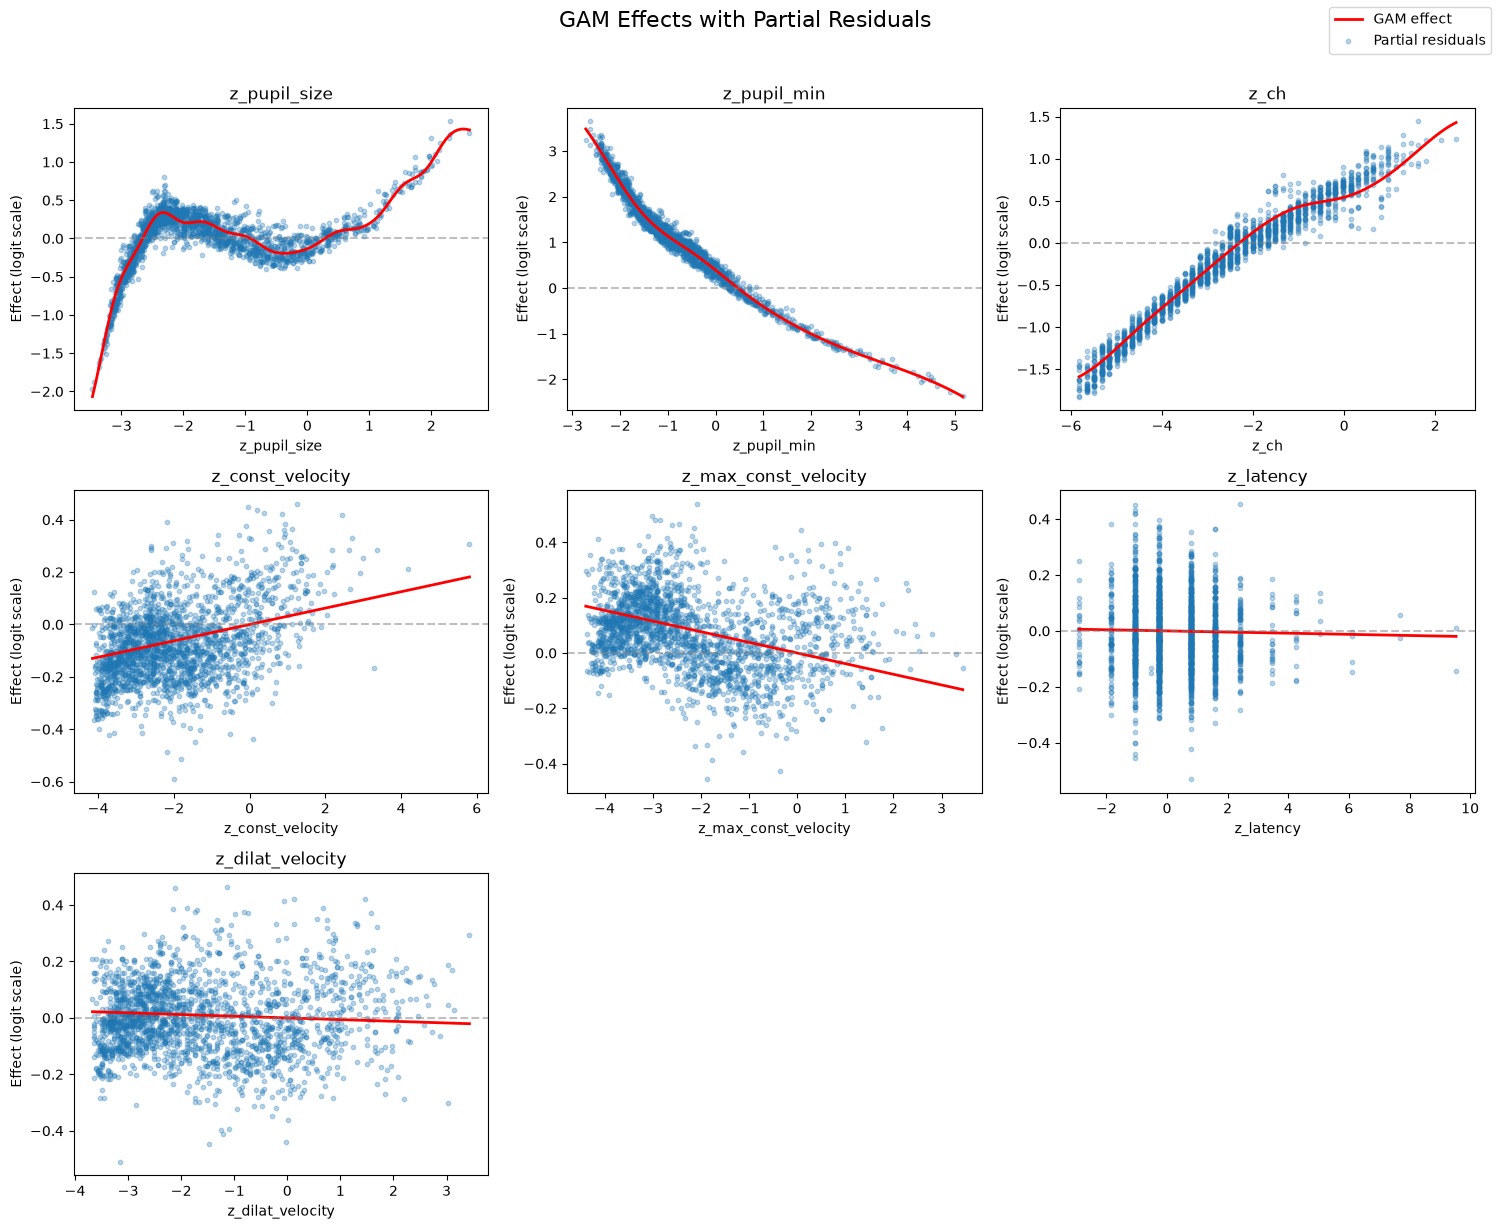

In [41]:
#   Plot gam functions
n_features = len(FEATURES)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharey=False 
)

axes = axes.flatten()

y_pred = gam.predict(X_trans)

for i in range(n_features):
    ax = axes[i]

    XX = gam.generate_X_grid(term=i)
    pdp = gam.partial_dependence(term=i, X=XX)

    ax.plot(
        XX[:, gam.terms[i].feature],
        pdp,
        color="red",
        linewidth=2,
        label="GAM effect"
    )

    x_vals = X_trans.iloc[:, i].values

    residual = z - y_pred + gam.partial_dependence(term=i, X=X)

    ax.scatter(
        x_vals,
        residual,
        alpha=0.3,
        s=10,
        label="Partial residuals"
    )

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_title(FEATURES[i])
    ax.set_xlabel(FEATURES[i])
    ax.set_ylabel("Effect (logit scale)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.suptitle("GAM Effects with Partial Residuals", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("GAM_after.pdf", bbox_inches='tight', dpi=1200)


In [42]:
y_pred = 1 / (1 + np.exp(-y_pred))
npi_pred = y_pred * (5 - 0) + 0

In [43]:
print(r2_score(y_raw, np.round(npi_pred, 1) ))
print(mean_squared_error(y_raw, np.round(npi_pred, 1) ))
print(mean_absolute_error(y_raw, np.round(npi_pred, 1) ))

0.9891339855452196
0.0070202507232401175
0.05380906460945035


In [44]:
coef = gam.coef_
intercept = gam._modelmat(np.zeros((1, X_trans.shape[1]))) @ gam.coef_

In [45]:
for i in range(0, 8):
    print(i)
    print(f"beta_{i} =", gam.coef_[gam.terms.get_coef_indices(i)])

0
beta_0 = [-2.9686989  -2.22245227 -0.5465481  -0.20823848  0.51031977  0.12904095
  0.28388615  0.0481395   0.06545204 -0.20054938 -0.19847071 -0.11995839
  0.13103732  0.10331399  0.26926183  0.7848829   0.7845395   1.41780725
  1.46178562  1.24762073]
1
beta_1 = [ 4.70144899  3.69328176  1.42887211  0.83515677 -0.21542128 -0.92812656
 -1.4360077  -1.82552629 -2.32177982 -3.15972677]
2
beta_2 = [-1.69687491 -1.69687491 -1.05225793 -0.52962472  0.0283864   0.48883845
  0.48883845  0.89780136  1.53588222  1.53588222]
3
beta_3 = [0.0312562]
4
beta_4 = [-0.03855666]
5
beta_5 = [-0.00204845]
6
beta_6 = [-0.00598288]
7
beta_7 = [0.77217125]


In [46]:
# ---------- AIC/BIC helper ----------
def aic_bic(y_true, y_pred, n_params):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    aic = n * np.log(rss / n) + 2 * n_params
    bic = n * np.log(rss / n) + n_params * np.log(n)
    return aic, bic

# Min

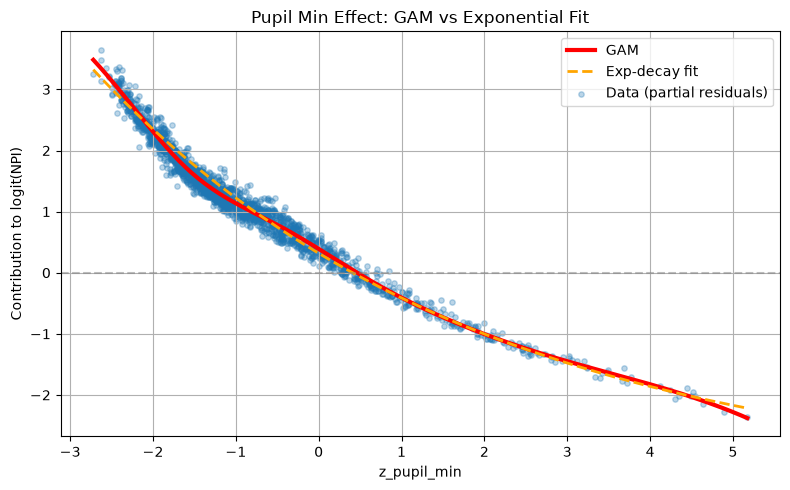

In [47]:

def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c


# X interval
x_vals = np.linspace(
    X_trans["z_pupil_min"].min(),
    X_trans["z_pupil_min"].max(),
    200
)

X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x_vals), 1)),
    columns=X_trans.columns
)
X_fake["z_pupil_min"] = x_vals

# GAM partial dependence 
y_gam = gam.partial_dependence(term=1, X=X_fake)

# fitted curve 
params_min, _ = curve_fit(exp_decay, x_vals, y_gam, maxfev=10000)
y_fit = exp_decay(x_vals, *params_min)



# ADD DATAPOINTS


# Predictions
y_pred = gam.predict(X_trans)

# Partial residuals
partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=1, X=X_trans)
)

# Raw x-values
x_data = X_trans["z_pupil_min"].values

aic_sig, bic_sig = aic_bic(
    partial_res, exp_decay(x_data, *params_min), n_params=3
)

# PLOT

plt.figure(figsize=(8,5))

# GAM curve
plt.plot(x_vals, y_gam, color="red",label="GAM", linewidth=3)

# Parametric fit
plt.plot(x_vals, y_fit, '--',color="orange", label="Exp-decay fit", linewidth=2)

plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("z_pupil_min")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Min Effect: GAM vs Exponential Fit")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
from pysr import PySRRegressor

# --- PySR fit directly on the raw residuals (not y_gam) ---
# Restrict operators to ones that tend to produce monotonic behavior;
# still include sin/cos so we don't rule out a real non-monotonic shape by assumption,
# but we'll explicitly check monotonicity afterward either way.
model_pysr_min = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "square", "cube"],
    model_selection="best",
    maxsize=10,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    parallelism="serial",
)

model_pysr_min.fit(x_vals.reshape(-1, 1), y_gam)
print(model_pysr_min)

c:\Users\NKUE0003\Documents\GitHub\Pupillometry_study\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.040e+05
Progress: 468 / 31000 total iterations (1.510%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.476e+00  0.000e+00  y = -0.1926
3           4.224e-01  8.843e-01  y = x₀ * -0.5566
5           1.132e-01  6.583e-01  y = (x₀ + -0.93971) * -0.67128
7           4.027e-02  5.169e-01  y = (x₀ * 4.6406) / (-6.1344 - x₀)
8           1.659e-02  8.866e-01  y = (x₀ * -0.46895) + exp(-1.7484 - x₀)
10          5.997e-03  5.089e-01  y = exp(x₀ * -0.10356) * ((x₀ / -1.2686) + 0.33117)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evalua

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                        -0.19260107   
	1        0.884254                                    x0 * -0.5565966   
	2        0.658286                    (x0 + -0.9397057) * -0.67128336   
	3  >>>>  1.784532        (-61.26072 / (-8.818469 - x0)) + -6.6415815   
	4        0.000794  ((x0 / (-8.759161 - x0)) * 6.8996763) + 0.3026...   
	5        0.103409  ((x0 * -0.3321428) + -0.7088119) + exp(x0 * -0...   
	
	       loss  complexity  
	0  2.476399           1  
	1  0.422443           3  
	2  0.113237           5  
	3  0.003191           7  
	4  0.003186           9  
	5  0.002873          10  
]


In [49]:
model_pysr_min.get_best().sympy_format.simplify()

(2.69213943127649 - 6.6415815*x0)/(x0 + 8.818469)

In [50]:
# Replace this with whatever functional form PySR actually returns
def min_pysr_expr(x, a, b, c, d, e):
    return a + b / (c + d * np.exp(-x) + e / x)

def min_pysr_expr(x, a, b, c):
    return (a + b * x) / (x + c)


Model                             AIC         BIC
Sigmoid+threshold            -7431.64    -7414.73
PySR                         -7979.69    -7962.78


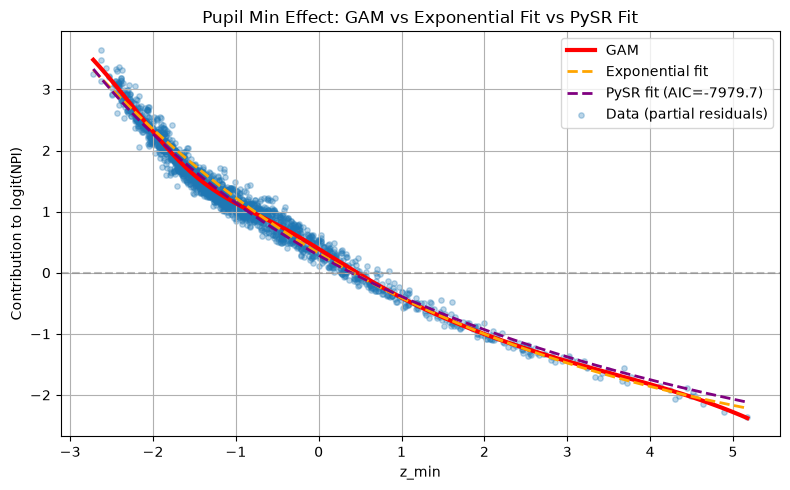

In [51]:
# params_pysr_min, _ = curve_fit(min_pysr_expr, x_data, partial_res, p0=[0.31, -2.75, 0.35, 0.0084, 3.616], maxfev=20000)
params_pysr_min, _ = curve_fit(min_pysr_expr, x_data, partial_res, p0=[2.692, -6.641, 8.818], maxfev=20000)

y_fit_pysr = min_pysr_expr(x_vals, *params_pysr_min)  # on the smooth grid, for plotting
aic_pysr, bic_pysr = aic_bic(
    partial_res, min_pysr_expr(x_data, *params_pysr_min), n_params=len(params_pysr_min)
)

# ---------- Metrics table ----------
print(f"\n{'Model':<25}{'AIC':>12}{'BIC':>12}")
print(f"{'Sigmoid+threshold':<25}{aic_sig:>12.2f}{bic_sig:>12.2f}")
print(f"{'PySR':<25}{aic_pysr:>12.2f}{bic_pysr:>12.2f}")

# ---------- Plot ----------
plt.figure(figsize=(8, 5))
# GAM
plt.plot(x_vals, y_gam, label="GAM",color="red", linewidth=3)
# exponential fit
plt.plot(x_vals, y_fit, '--',color="orange", label="Exponential fit", linewidth=2)
# PySR fit
plt.plot(x_vals, y_fit_pysr, '--', color="purple", label=f"PySR fit (AIC={aic_pysr:.1f})", linewidth=2)
# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_min")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Min Effect: GAM vs Exponential Fit vs PySR Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# CH

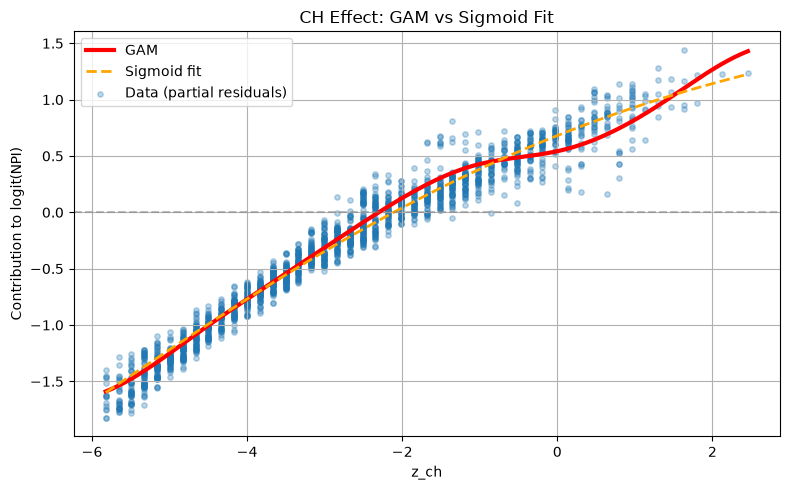

In [52]:
# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_shifted(x, A, k, x0, b):
    return A * sigmoid(k * (x - x0)) + b

x_vals = np.linspace(
    X_trans["z_ch"].min(),
    X_trans["z_ch"].max(),
    200
)
X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x_vals), 1)),
    columns=X_trans.columns
)
X_fake["z_ch"] = x_vals

# GAM partial dependence
y_gam = gam.partial_dependence(term=2, X=X_fake)

# Fit sigmoid
p0 = [
    y_gam.max() - y_gam.min(),
    1.0,
    np.median(x_vals),
    np.mean(y_gam)
]
bounds = (
    [0,   0.01, x_vals.min(), -10],
    [10, 10,    x_vals.max(), 10]
)
p0 = np.clip(p0, bounds[0], bounds[1])
params_ch, _ = curve_fit(
    sigmoid_shifted,
    x_vals,
    y_gam,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
y_fit = sigmoid_shifted(x_vals, *params_ch)

# ADD DATAPOINTS
y_pred = gam.predict(X_trans)
partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=2, X=X_trans)
)
x_data = X_trans["z_ch"].values


aic_sig, bic_sig = aic_bic(
    partial_res, sigmoid_shifted(x_data, *params_ch), n_params=4
)

# Plot
plt.figure(figsize=(8,5))
# GAM curve
plt.plot(x_vals, y_gam, color="red", label="GAM", linewidth=3)
# sigmoid fit
plt.plot(x_vals, y_fit, '--', color="orange", label="Sigmoid fit", linewidth=2)
# data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_ch")
plt.ylabel("Contribution to logit(NPI)")
plt.title("CH Effect: GAM vs Sigmoid Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
from pysr import PySRRegressor

# --- PySR fit directly on the raw residuals (not y_gam) ---
# Restrict operators to ones that tend to produce monotonic behavior;
# still include sin/cos so we don't rule out a real non-monotonic shape by assumption,
# but we'll explicitly check monotonicity afterward either way.
model_ch = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "square", "cube", "sin", "cos"],
    model_selection="best",
    maxsize=10,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    parallelism="serial",
)

model_ch.fit(x_vals.reshape(-1, 1), y_gam)
print(model_ch)

c:\Users\NKUE0003\Documents\GitHub\Pupillometry_study\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.810e+05
Progress: 1039 / 31000 total iterations (3.352%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.064e-01  0.000e+00  y = 0.033918
3           2.708e-01  4.793e-01  y = x₀ * 0.22532
4           1.793e-01  4.125e-01  y = cos(x₀ * 0.57643)
5           1.659e-02  2.380e+00  y = (x₀ - -1.7805) * 0.34573
7           1.659e-02  3.874e-07  y = ((-0.45743 - x₀) * -1.3457) - x₀
9           1.653e-02  1.850e-03  y = ((x₀ - (0.00084033 / x₀)) + 1.782) * 0.34593
10          8.770e-03  6.340e-01  y = ((cos(-1.0178 / x₀) * 0.36802) * x₀) + 0.63364
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.000000e+00                                         0.03391847   
	1        4.793364e-01                                    x0 * 0.22532186   
	2        4.124671e-01                                cos(x0 * 0.5764349)   
	3        2.380006e+00                     (x0 - -1.7805406) * 0.34573317   
	4        5.203131e-01        (-98.261185 / (x0 + 18.851786)) + 5.8731403   
	5        1.194233e-07  ((-98.26114 / (x0 + 18.852001)) + 5.8741355) -...   
	6  >>>>  4.770698e-01  ((x0 + 1.3945531) - sin(x0 / 2.350718)) * 0.44...   
	
	       loss  complexity  
	0  0.706398           1  
	1  0.270834           3  
	2  0.179296           4  
	3  0.016594           5  
	4  0.005862           7  
	5  0.005862           9  
	6  0.003638          10  
]
  - outputs\20260716_163855_xPpvnA\hall_of_fame.csv


In [54]:
model_ch.get_best().sympy_format.simplify()

0.44940537*x0 - 0.44940537*sin(0.425401941023976*x0) + 0.626719651890147

In [55]:
# Replace this with whatever functional form PySR actually returns
def ch_pysr_expr(x, a, b, c, d):
    return a * x + b * np.sin(c * x) + d


Model                             AIC         BIC
Sigmoid+threshold            -8621.36    -8598.81
PySR                         -8848.96    -8826.41


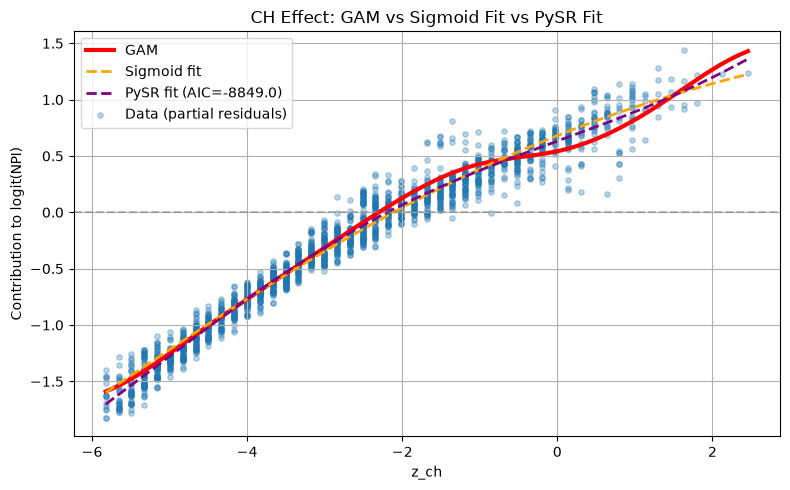

In [56]:
params_pysr_ch, _ = curve_fit(ch_pysr_expr, x_data, partial_res, p0=[0.449, -0.449, 0.425, 0.626], maxfev=20000)

y_fit_pysr = ch_pysr_expr(x_vals, *params_pysr_ch)  # on the smooth grid, for plotting
aic_pysr, bic_pysr = aic_bic(
    partial_res, ch_pysr_expr(x_data, *params_pysr_ch), n_params=len(params_pysr_ch)
)

# ---------- Metrics table ----------
print(f"\n{'Model':<25}{'AIC':>12}{'BIC':>12}")
print(f"{'Sigmoid+threshold':<25}{aic_sig:>12.2f}{bic_sig:>12.2f}")
print(f"{'PySR':<25}{aic_pysr:>12.2f}{bic_pysr:>12.2f}")

# ---------- Plot ----------
plt.figure(figsize=(8, 5))
# GAM
plt.plot(x_vals, y_gam, label="GAM",color="red", linewidth=3)
# sigmoid fit
plt.plot(x_vals, y_fit, '--',color="orange", label="Sigmoid fit", linewidth=2)
# PySR fit
plt.plot(x_vals, y_fit_pysr, '--', color="purple", label=f"PySR fit (AIC={aic_pysr:.1f})", linewidth=2)
# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_ch")
plt.ylabel("Contribution to logit(NPI)")
plt.title("CH Effect: GAM vs Sigmoid Fit vs PySR Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Size

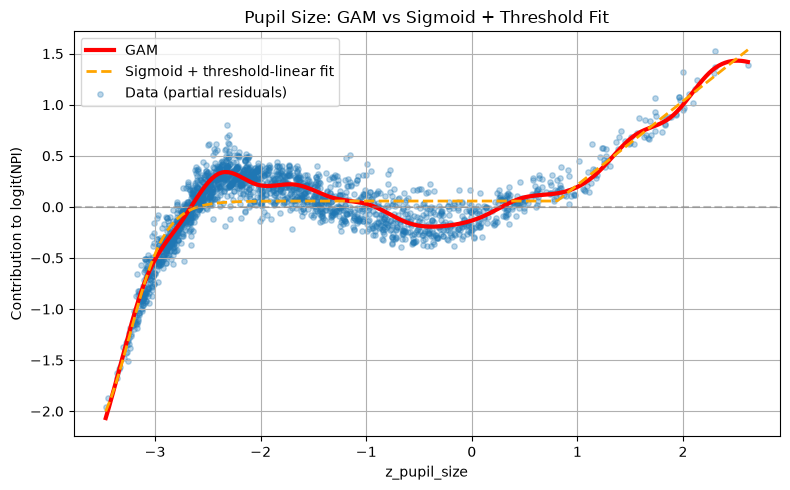

In [57]:
from scipy.optimize import curve_fit
from pysr import PySRRegressor

# Same as before using max size
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# Model function
def sigmoid_plus_threshold_linear(x, A, k, x0, m, b, x_thresh):
    return A * sigmoid(k * (x - x0)) + m * np.maximum(0, x - x_thresh) + b

x = np.linspace(
    X_trans["z_pupil_size"].min(),
    X_trans["z_pupil_size"].max(),
    200
)
X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x), 1)),
    columns=X_trans.columns
)
X_fake["z_pupil_size"] = x
y_gam = gam.partial_dependence(term=0, X=X_fake)

p0 = [
    y_gam.max() - y_gam.min(),  # A
    1.0,                        # k
    np.median(x),               # x0
    0.2,                        # m
    y_gam.min(),             # b
    0.0      
]
bounds=(
                [0, 0.01, x.min(), -5, -10, x.min()],
                [10,10, x.max(),  5,  10,  x.max()]
            )
p0 = np.clip(p0, bounds[0], bounds[1])
params_size, _ = curve_fit(
    sigmoid_plus_threshold_linear,
    x,
    y_gam,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)
y_fit = sigmoid_plus_threshold_linear(x, *params_size)
y_pred = gam.predict(X_trans)
partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=0, X=X_trans)
)
x_data = X_trans["z_pupil_size"].values

# Refit sigmoid+threshold on the RAW data (fair comparison basis)
params_size_raw, _ = curve_fit(
    sigmoid_plus_threshold_linear, x_data, partial_res,
    p0=p0, bounds=bounds, maxfev=20000
)
aic_sig, bic_sig = aic_bic(
    partial_res, sigmoid_plus_threshold_linear(x_data, *params_size_raw), n_params=6
)

plt.figure(figsize=(8, 5))

# GAM
plt.plot(x, y_gam, label="GAM",color="red", linewidth=3)

# fit
plt.plot(x, y_fit, '--',color="orange", label="Sigmoid + threshold-linear fit", linewidth=2)

# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("z_pupil_size")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Size: GAM vs Sigmoid + Threshold Fit")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ---------- PySR fit (deterministic, on raw partial residuals) ----------
model_pysr = PySRRegressor(
    niterations=1000,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp", "square", "cube"],
    model_selection="best",
    maxsize=15,
    parsimony=0.01,
    random_state=42,
    deterministic=True,
    parallelism="serial"
)
model_pysr.fit(x.reshape(-1, 1), y_gam)
print(model_pysr)

c:\Users\NKUE0003\Documents\GitHub\Pupillometry_study\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 9.410e+04
Progress: 485 / 155000 total iterations (0.313%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.860e-01  0.000e+00  y = 0.1602
3           2.374e-01  2.430e-01  y = 0.22994 * x₀
4           1.733e-01  3.146e-01  y = exp(x₀) * 0.12304
5           1.669e-01  3.801e-02  y = (x₀ * 0.26528) + 0.27326
6           6.629e-02  9.231e-01  y = cube((x₀ * 0.37116) + 0.24848)
8           4.852e-02  1.560e-01  y = x₀ * ((-0.64459 - sin(x₀)) * -0.36675)
9           3.349e-02  3.708e-01  y = (x₀ * -0.51636) * cos(-2.1864 - sin(x₀))
11          1.936e-02  2.740e-01  y = (cos(-1.994 - sin(x₀)) * (x₀ * -0.63701)) - 0.21335
13          1.928e-02  2.156e-03  y = x₀ * (cos(sin(x₀ - sin(sin(x₀))) - -2.2108) * -0.51342...
                                    

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.860e-01  0.000e+00  y = 0.1602
3           2.374e-01  2.430e-01  y = 0.22994 * x₀
4           1.733e-01  3.146e-01  y = exp(x₀) * 0.12305
5           1.479e-01  1.590e-01  y = x₀ / (4.1963 - x₀)
6           6.629e-02  8.021e-01  y = cube(x₀ + 0.66931) * 0.051147
7           4.936e-02  2.950e-01  y = cube(1.5314 - exp(x₀ * -0.29254))
8           4.775e-02  3.301e-02  y = cube(cube(1.5513 - exp(x₀ * -0.28374)))
9           1.910e-02  9.164e-01  y = (cube(x₀) * -0.084839) * (-0.38136 - sin(x₀))
10          9.999e-03  6.471e-01  y = ((0.66882 - exp(sin(x₀))) * -0.077619) * cube(x₀)
11          7.049e-03  3.496e-01  y = ((-0.41512 - sin(x₀)) * -0.079379) * cube(x₀ + 0.15459...
                                      )
13          3.827e-03  3.054e-01  y = sin(0.41761 - x₀) * ((x₀ + (cube(x₀) - -3.475)) * -0.0...
                          

In [75]:
model_pysr.get_best().sympy_format.simplify()

(0.07530924*x0**3 + 0.07530924*x0 + 0.261703103348736)*sin(x0 - 0.41761172)

In [60]:
# Replace this with whatever functional form PySR actually returns
def pysr_expr(x, a, b, c):
    return a * x**3 + np.sin(b * x**2) + c

def pysr_expr(x, a, b, c, d):
    return (a * x**3 + b*x + c) * np.cos(x + d)

def pysr_expr(x, a, b, c, d):
    return (a * x**3 + b*x + c) * np.sin(x + d)


Model                             AIC         BIC
Sigmoid+threshold            -6896.81    -6862.99
PySR                         -8458.51    -8435.96


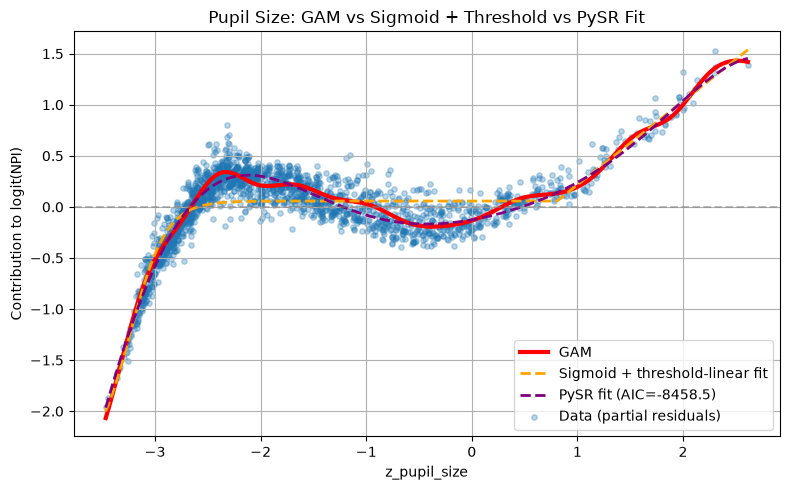

In [61]:
params_pysr_size, _ = curve_fit(pysr_expr, x_data, partial_res, p0=[0.062, 0.144, 0.263, -0.458], maxfev=20000)

y_fit_pysr = pysr_expr(x, *params_pysr_size)  # on the smooth grid, for plotting
aic_pysr, bic_pysr = aic_bic(
    partial_res, pysr_expr(x_data, *params_pysr_size), n_params=len(params_pysr_size)
)

# ---------- Metrics table ----------
print(f"\n{'Model':<25}{'AIC':>12}{'BIC':>12}")
print(f"{'Sigmoid+threshold':<25}{aic_sig:>12.2f}{bic_sig:>12.2f}")
print(f"{'PySR':<25}{aic_pysr:>12.2f}{bic_pysr:>12.2f}")

# ---------- Plot ----------
plt.figure(figsize=(8, 5))
# GAM
plt.plot(x, y_gam, label="GAM",color="red", linewidth=3)
# sigmoid fit
plt.plot(x, y_fit, '--',color="orange", label="Sigmoid + threshold-linear fit", linewidth=2)
# PySR fit
plt.plot(x, y_fit_pysr, '--', color="purple", label=f"PySR fit (AIC={aic_pysr:.1f})", linewidth=2)
# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("z_pupil_size")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Size: GAM vs Sigmoid + Threshold vs PySR Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
def f_min(x):
    return params_min[0] * np.exp(-params_min[1] * x) + params_min[2]
    # return params_pysr_min[0] + params_pysr_min[1] / (params_pysr_min[2] + params_pysr_min[3] * np.exp(-x) + params_pysr_min[4] / x)

def f_ch(x):
    return params_pysr_ch[0] * x + params_pysr_ch[1] * np.sin(params_pysr_ch[2] * x) + params_pysr_ch[3]

def f_size(x):
    return (params_pysr_size[0] * x**3 + params_pysr_size[1]*x + params_pysr_size[2]) * np.sin(x + params_pysr_size[3])

# def f_size(x):
#     return params_size[0] * sigmoid(params_size[1]  * (x - params_size[2] )) + params_size[3]  * np.maximum(0, x - params_size[5] ) + params_size[4] 



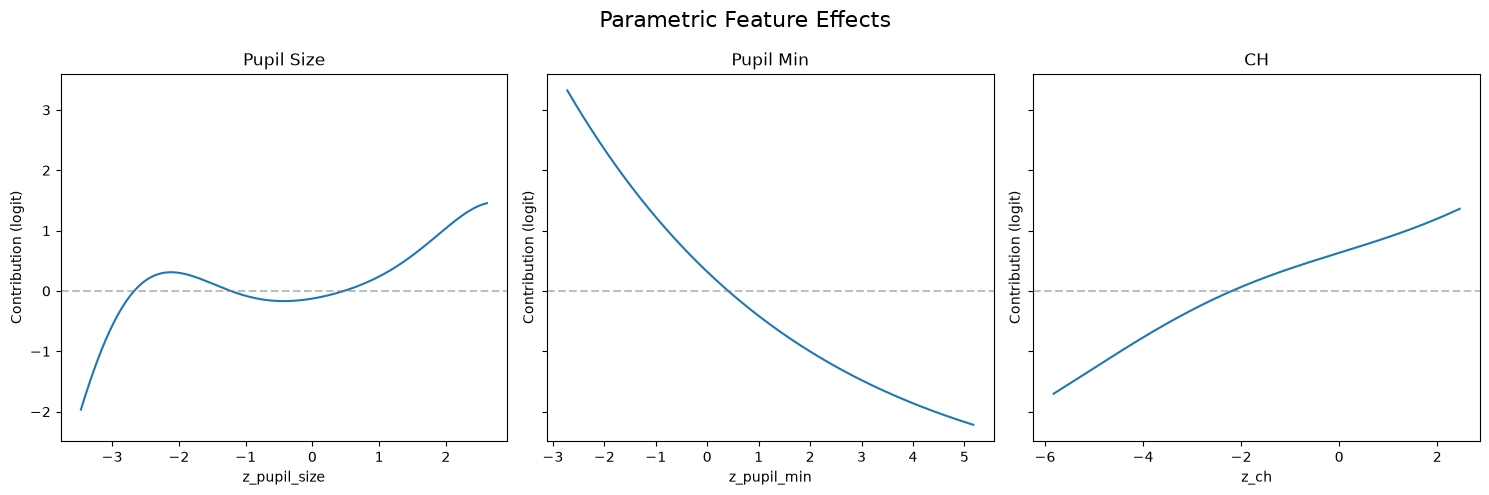

In [63]:
# Create grids based on feature ranges
x_size = np.linspace(X_trans["z_pupil_size"].min(), X_trans["z_pupil_size"].max(), 200)
x_min  = np.linspace(X_trans["z_pupil_min"].min(),  X_trans["z_pupil_min"].max(), 200)
x_ch   = np.linspace(X_trans["z_ch"].min(),         X_trans["z_ch"].max(), 200)

# functions
y_size = f_size(x_size)
y_min  = f_min(x_min)
y_ch   = f_ch(x_ch)


# Plot
fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

axes[0].plot(x_size, y_size)
axes[0].set_title("Pupil Size")
axes[0].set_xlabel("z_pupil_size")

axes[1].plot(x_min, y_min)
axes[1].set_title("Pupil Min")
axes[1].set_xlabel("z_pupil_min")

axes[2].plot(x_ch, y_ch)
axes[2].set_title("CH")
axes[2].set_xlabel("z_ch")

for ax in axes:
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel("Contribution (logit)")

plt.suptitle("Parametric Feature Effects", fontsize=16)
plt.tight_layout()
plt.show()

In [64]:
def predict_z(df):
    return (
        intercept
        + f_size(df["z_pupil_size"].values)
        + f_min(df["z_pupil_min"].values)
        + f_ch(df["z_ch"].values)
        + gam.coef_[gam.terms.get_coef_indices(3)]* df["z_const_velocity"].values
        + gam.coef_[gam.terms.get_coef_indices(4)] * df["z_max_const_velocity"].values
        + gam.coef_[gam.terms.get_coef_indices(5)] * df["z_latency"].values
        + gam.coef_[gam.terms.get_coef_indices(6)] * df["z_dilat_velocity"].values
    )

In [65]:
z_pred = predict_z(df)
y_pred_scaled = inverse_logit_transform(z_pred)

# rescale to original NPi range
npi_pred =np.round(y_pred_scaled,1)

In [66]:
y_true = df["npi"].values

mae = mean_absolute_error(y_true, npi_pred)
rmse = np.sqrt(mean_squared_error(y_true, npi_pred))
r2 = r2_score(y_true, npi_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.42651880424300875
RMSE: 0.4917839919072592
R²: 0.625659831695204


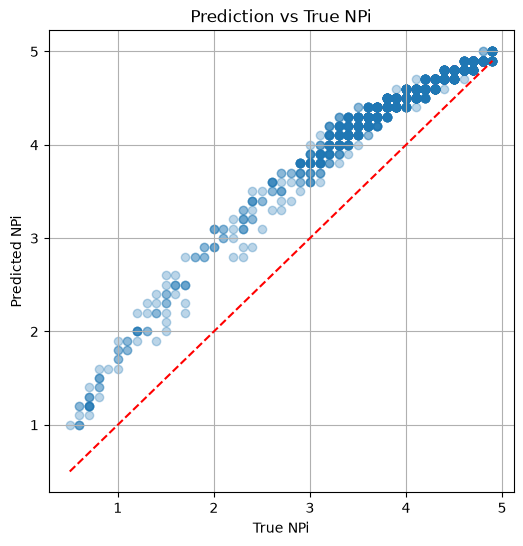

In [67]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, npi_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True NPi")
plt.grid()
plt.show()

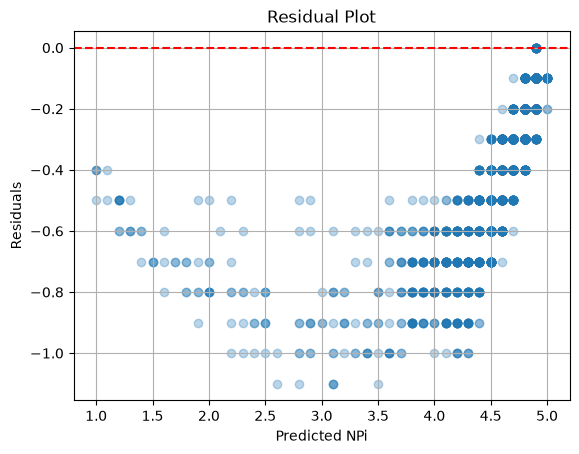

In [68]:
residuals = y_true - npi_pred

plt.scatter(npi_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted NPi")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

In [69]:
from sklearn.linear_model import LinearRegression

# predicted z
z_pred = predict_z(df)

# transform true NPi to logit space
y = df["npi"].values / 5
y = np.clip(y, 1e-6, 1 - 1e-6)
z_true = np.log(y / (1 - y))

# fit linear correction
reg = LinearRegression().fit(z_pred.reshape(-1,1), z_true)

a = reg.coef_[0]
b = reg.intercept_

print("Correction: z_corrected = %.4f * z_pred + %.4f" % (a, b))

Correction: z_corrected = 0.9678 * z_pred + -0.7456


In [70]:
z_corrected = a * z_pred + b

npi_pred = np.round(1/(1+np.exp(-z_corrected)) * 5,1)



mae = mean_absolute_error(y_true, npi_pred)
rmse = np.sqrt(mean_squared_error(y_true, npi_pred))
r2 = r2_score(y_true, npi_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.05988428158148506
RMSE: 0.09243309238049029
R²: 0.9867757021882756


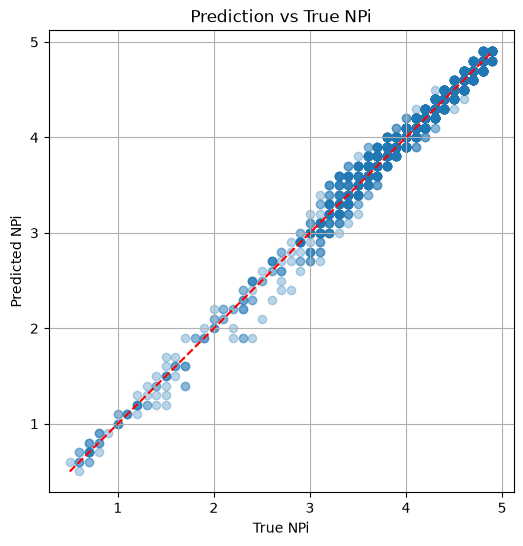

In [71]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, npi_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True NPi")
plt.grid()
plt.show()

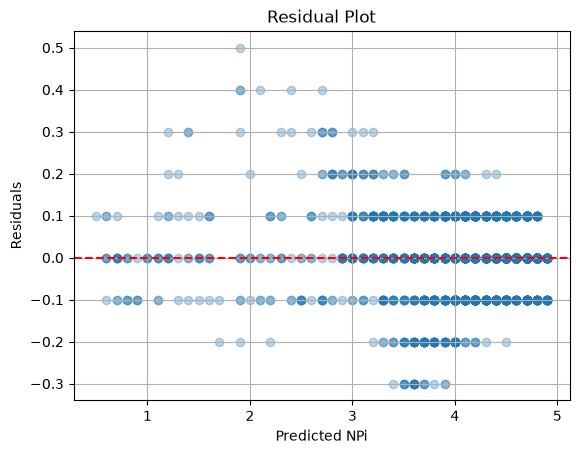

In [72]:
residuals = y_true - npi_pred

plt.scatter(npi_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted NPi")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

Check the outliers

In [73]:
# Find high-error patients
df_results = df.copy()
df_results["npi_pred"] = npi_pred
df_results["error"] = np.abs(df_results["npi_pred"] - df_results["npi"])


# Show top 10 highest errors
top_errors = (
    df_results
    .nlargest(10, "error")
    [["record_id", "redcap_repeat_instance", "eye", "npi", "npi_pred", "error"]]
    .reset_index(drop=True)
)

#print(top_errors) # Commented out for privacy reasons

From this we can go and check, and we found that the 3 largest errors have massive mistakes in how their CH is written. 
Seems like human error (miss typed)